# Sauti — External Data Integration

Pull AfriSenti (Swahili) and Kaggle datasets, map their labels to Sauti schema,
and merge into the training set to bulk up weak categories.

In [1]:
import sys
import uuid
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from datetime import datetime

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))
print(f'Project root: {ROOT}')

Project root: /mnt/d/DS PROJECTS/sauti


## 1. Load AfriSenti — Swahili sentiment

In [2]:
from datasets import load_dataset

print('Loading AfriSenti Swahili...')
ds = load_dataset('DGurgurov/swahili_sa')

print('Splits:', ds)
train_data = ds['train'].to_pandas()
print(f'\nTotal rows: {len(train_data)}')
print('Columns:', train_data.columns.tolist())
train_data.head()

Loading AfriSenti Swahili...
Splits: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 738
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 185
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 304
    })
})

Total rows: 738
Columns: ['text', 'label']


,text,label
0,Kwani tanesco wanakataga umeme makusudinadhani...,0
1,cjawahi kuona content yoyote zaidi ya kuwa ana...,0
2,Bomu lililokuwa limetegwa ndani ya gari likiwa...,0
3,Kuna video inasambaa mitandaoni jamaa amemfuma...,0
4,Viwavijeshi wanapita katika hatua kuu 6 za uku...,0


## 2. Check label encoding

In [3]:
print('Label values:', train_data['label'].unique())
print('\nDistribution:')
print(train_data['label'].value_counts())

# Check if labels are strings or integers
print('\nLabel type:', type(train_data['label'].iloc[0]))

# Preview a few of each label
for label in train_data['label'].unique():
    sample = train_data[train_data['label'] == label]['text'].iloc[0]
    print(f'\n[{label}] {sample[:120]}')

Label values: [0 1]

Distribution:
label
1    547
0    191
Name: count, dtype: int64

Label type: <class 'numpy.int64'>

[0] Kwani tanesco wanakataga umeme makusudinadhani kuna changamoto behind zinatakiwa zitatuliwe na sio kutoa matamko

[1] Asante sana watu wa Sirari jimbo la Tarime vijijini Huu ni Upendo usio na Mashaka kwa Mbunge wenu John Heche na Chadem


## 3. Map to Sauti schema

Strategy:
- `positive` / `neutral` → `clean` (high confidence Swahili clean examples)
- `negative` → `ambiguous` (conservative — don't auto-label as harmful)

In [6]:
# # Detect label format (string vs int)
# sample_label = train_data['label'].iloc[0]

# if isinstance(sample_label, str):
#     positive_vals = ['positive']
#     neutral_vals  = ['neutral']
#     negative_vals = ['negative']
# else:
#     # Numeric — check the features
#     label_names = ds['train'].features['label'].names
#     print('Numeric label names:', label_names)
#     train_data['label_name'] = train_data['label'].apply(lambda x: label_names[x])
#     positive_vals = [label_names.index('positive')]
#     neutral_vals  = [label_names.index('neutral')]  if 'neutral'  in label_names else []
#     negative_vals = [label_names.index('negative')] if 'negative' in label_names else []
#     label_col = 'label_name'

# label_col = 'label'

# clean_examples    = train_data[train_data[label_col].isin(positive_vals + neutral_vals)]
# negative_examples = train_data[train_data[label_col].isin(negative_vals)]

# print(f'Clean candidates:    {len(clean_examples)}')
# print(f'Negative candidates: {len(negative_examples)}')


# 0 = negative, 1 = positive
positive_vals = [1]
negative_vals = [0]

clean_examples    = train_data[train_data['label'].isin(positive_vals)]
negative_examples = train_data[train_data['label'].isin(negative_vals)]

print(f'Clean candidates (positive):    {len(clean_examples)}')
print(f'Negative candidates:            {len(negative_examples)}')

Clean candidates (positive):    547
Negative candidates:            191


In [7]:
# 0 = negative → ambiguous, 1 = positive → clean
clean_examples    = train_data[train_data['label'] == 1]
negative_examples = train_data[train_data['label'] == 0]

print(f'Clean candidates:    {len(clean_examples)}')
print(f'Negative candidates: {len(negative_examples)}')

Clean candidates:    547
Negative candidates: 191


In [8]:
import uuid

rows = []

# Clean examples — sample up to 200
for _, row in clean_examples.sample(min(200, len(clean_examples)), random_state=42).iterrows():
    text = str(row['text']).strip()
    if len(text) < 10:
        continue
    rows.append({
        'id':       str(uuid.uuid4()),
        'text':     text,
        'language': 'sw',
        'category': 'clean',
        'severity': 1,
        'source':   'afrisenti',
    })

# Negative → ambiguous (conservative)
for _, row in negative_examples.head(100).iterrows():
    text = str(row['text']).strip()
    if len(text) < 10:
        continue
    rows.append({
        'id':       str(uuid.uuid4()),
        'text':     text,
        'language': 'sw',
        'category': 'ambiguous',
        'severity': 1,
        'source':   'afrisenti_negative',
    })

afrisenti_df = pd.DataFrame(rows)
print(f'AfriSenti rows prepared: {len(afrisenti_df)}')
print(afrisenti_df['category'].value_counts())
afrisenti_df.head()

AfriSenti rows prepared: 300
category
clean        200
ambiguous    100
Name: count, dtype: int64


,id,text,language,category,severity,source
0,a91b3f0c-f88f-405e-96c7-186651d90391,Happy Birthday Mh Rais Mstaafu wa Awamu ya Nne...,sw,clean,1,afrisenti
1,5a8f7e27-0004-46f2-8b58-b8c300992c99,Unaweza kubadili namna ya kutafikia malengo la...,sw,clean,1,afrisenti
2,aa372254-8c4f-4448-8d5d-a69c8c082223,Wasifu wa Siti binti Saad ni kitabu ninachokip...,sw,clean,1,afrisenti
3,d1e808de-e57c-44f1-92e9-8172a5a20d53,E bwana MC shupavu huu ujumbe wa humu ni zaidi...,sw,clean,1,afrisenti
4,ffb2df2d-01eb-486c-a3a7-16ba1cdd5f7b,huo ipasavyo na kuwaagiza kuendelea kuwasimami...,sw,clean,1,afrisenti


## 4. Kaggle — Jigsaw Toxic Comments

Download from: https://www.kaggle.com/competitions/jigsaw-toxic-comment-classification-challenge/data  
Place `train.csv` at: `data/raw/kaggle_jigsaw_train.csv`

Label mapping:
- `identity_hate` → `hate_speech`
- `threat`        → `distress_trigger`  
- `toxic/obscene/insult` → `offensive_language`
- all zeros       → `clean`

In [16]:
jigsaw_path = ROOT / 'data' / 'raw' / 'kaggle_jigsaw_train.csv'

if not jigsaw_path.exists():
    print('⚠ Jigsaw not found — skipping.')
    print(f'Download train.csv and place at: {jigsaw_path}')
    jigsaw_df = pd.DataFrame()
else:
    jigsaw = pd.read_csv(jigsaw_path)
    print(f'Loaded {len(jigsaw)} Jigsaw rows')
    print(jigsaw.columns.tolist())

    def map_jigsaw(row):
        if row['identity_hate'] == 1:                                    return 'hate_speech'
        if row['threat'] == 1:                                           return 'distress_trigger'
        if row['toxic'] == 1 or row['obscene'] == 1 or row['insult'] == 1 or row['severe_toxic'] == 1:
                                                                         return 'offensive_language'
        return 'clean'

    jigsaw['sauti_label'] = jigsaw.apply(map_jigsaw, axis=1)
    print('\nDistribution:')
    print(jigsaw['sauti_label'].value_counts())

    TARGET = 50
    jigsaw_rows = []
    for label in ['hate_speech', 'distress_trigger', 'offensive_language']:
        subset = jigsaw[
            (jigsaw['sauti_label'] == label) &
            (jigsaw['comment_text'].str.len() < 300)
        ].sample(min(TARGET, len(jigsaw[jigsaw['sauti_label'] == label])), random_state=42)

        for _, row in subset.iterrows():
            jigsaw_rows.append({
                'id':       str(uuid.uuid4()),
                'text':     str(row['comment_text']).strip(),
                'language': 'en',
                'category': label,
                'severity': 3,
                'source':   'kaggle_jigsaw',
            })

    jigsaw_df = pd.DataFrame(jigsaw_rows)
    print(f'\nJigsaw rows prepared: {len(jigsaw_df)}')
    print(jigsaw_df['category'].value_counts())

Loaded 159571 Jigsaw rows
['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Distribution:
sauti_label
clean                 143346
offensive_language     14440
hate_speech             1405
distress_trigger         380
Name: count, dtype: int64

Jigsaw rows prepared: 150
category
hate_speech           50
distress_trigger      50
offensive_language    50
Name: count, dtype: int64


## 5. Merge everything

Existing (combined_v1): 115 examples
Adding AfriSenti:       300
Adding Jigsaw:          150

Total combined: 565

Label distribution:
clean                 249
ambiguous             118
distress_trigger       64
offensive_language     62
hate_speech            56
manipulation           22
gaslighting            20
dtype: int64


<Axes: title={'center': 'Combined label distribution'}>

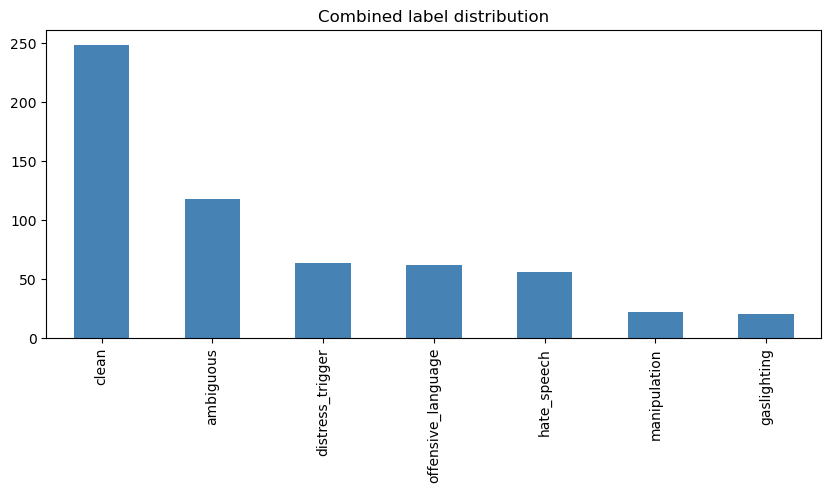

In [17]:
# jigsaw_df = pd.DataFrame()  # empty — Jigsaw not loaded yet

existing = pd.read_csv(ROOT / 'data' / 'annotated' / 'combined_v1.csv')
print(f'Existing (combined_v1): {len(existing)} examples')

dfs = [existing]
if len(afrisenti_df) > 0:
    dfs.append(afrisenti_df[['id','text','language','category','severity']])
    print(f'Adding AfriSenti:       {len(afrisenti_df)}')
if len(jigsaw_df) > 0:
    dfs.append(jigsaw_df[['id','text','language','category','severity']])
    print(f'Adding Jigsaw:          {len(jigsaw_df)}')

combined = pd.concat(dfs, ignore_index=True).drop_duplicates(subset='text')

print(f'\nTotal combined: {len(combined)}')
print('\nLabel distribution:')
all_labels = []
for cats in combined['category'].fillna('clean'):
    all_labels.extend(str(cats).split(','))
dist = pd.Series(Counter(all_labels)).sort_values(ascending=False)
print(dist)
dist.plot(kind='bar', figsize=(10,4), color='steelblue', title='Combined label distribution')

In [18]:
out_path = ROOT / 'data' / 'annotated' / 'combined_v2.csv'
combined.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(f'Total: {len(combined)} examples')

Saved: /mnt/d/DS PROJECTS/sauti/data/annotated/combined_v2.csv
Total: 565 examples


## 6. Retrain on combined_v2

In [19]:
from ml.src.data.cleaner import TextCleaner
from ml.src.data.loader import SautiDataset, ALL_LABELS
from ml.src.models.baseline import BaselineClassifier

cleaner = TextCleaner()
dataset = SautiDataset(ROOT / 'data' / 'annotated' / 'combined_v2.csv').load()
train_df, val_df, test_df = dataset.split()

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

def clean_texts(df):
    return [cleaner.clean(t)['cleaned'] for t in df['text'].tolist()]

X_train = clean_texts(train_df)
X_val   = clean_texts(val_df)
X_test  = clean_texts(test_df)
y_train = np.vstack(train_df['labels_binary'].tolist())
y_val   = np.vstack(val_df['labels_binary'].tolist())
y_test  = np.vstack(test_df['labels_binary'].tolist())

model_v3 = BaselineClassifier(labels=ALL_LABELS).build().train(X_train, y_train)
print('Training complete.')

2026-03-21 00:54:08.941 | INFO     | ml.src.models.baseline:train:82 - Training baseline on 395 examples...


Train: 395 | Val: 85 | Test: 85


2026-03-21 00:54:09.319 | INFO     | ml.src.models.baseline:train:85 - Training complete.


Training complete.


## 7. Evaluate and compare

In [20]:
test_metrics = model_v3.evaluate(X_test, y_test)

print(f"Macro F1: {test_metrics['macro_f1']}")
print(f"Micro F1: {test_metrics['micro_f1']}")
print()

# Compare against seed model
seed_path = ROOT / 'ml' / 'runs' / 'baseline_seed_v1.pkl'
if seed_path.exists():
    with open(seed_path, 'rb') as f:
        seed_model = pickle.load(f)
    seed_metrics = seed_model.evaluate(X_test, y_test)

    print(f"{'Model':<30} {'Macro F1':>10} {'Micro F1':>10}")
    print('-' * 52)
    print(f"{'Seed only (30)':<30} {seed_metrics['macro_f1']:>10} {seed_metrics['micro_f1']:>10}")
    print(f"{'v3 (AfriSenti + yours)':<30} {test_metrics['macro_f1']:>10} {test_metrics['micro_f1']:>10}")

print()
pd.DataFrame(test_metrics['per_label']).T

2026-03-21 00:54:13.692 | INFO     | ml.src.models.baseline:evaluate:144 - Macro F1: 0.4149 | Micro F1: 0.5845
2026-03-21 00:54:13.832 | INFO     | ml.src.models.baseline:evaluate:144 - Macro F1: 0.2320 | Micro F1: 0.1579


Macro F1: 0.4149
Micro F1: 0.5845

Model                            Macro F1   Micro F1
----------------------------------------------------
Seed only (30)                      0.232     0.1579
v3 (AfriSenti + yours)             0.4149     0.5845



,precision,recall,f1,support
hate_speech,0.3333,0.5714,0.4211,7.0
offensive_language,0.5000,0.5385,0.5185,13.0
distress_trigger,0.2632,0.8333,0.4000,6.0
gaslighting,0.0000,0.0000,0.0000,2.0
manipulation,0.5000,0.1667,0.2500,6.0
ambiguous,0.4062,0.8125,0.5417,16.0
clean,0.7083,0.8500,0.7727,40.0


## 8. Save model

In [21]:
run_id    = datetime.now().strftime('%Y%m%d_%H%M%S')
save_path = ROOT / 'ml' / 'runs' / f'baseline_{run_id}.pkl'
model_v3.save(save_path)
print(f'Saved: {save_path.name}')

2026-03-21 00:55:19.170 | INFO     | ml.src.models.baseline:save:166 - Model saved to /mnt/d/DS PROJECTS/sauti/ml/runs/baseline_20260321_005519.pkl


Saved: baseline_20260321_005519.pkl


## 9. Test on real Kenyan sentences

In [22]:
test_sentences = [
    'Wote Somali ni terrorists na wezi sana',
    'Wewe ni mjinga kabisa na hujui kitu',
    'Hukusema hivyo. Unakumbuka vibaya kila wakati.',
    'Tutakukumbuka vizuri baada ya uchaguzi hii',
    'Baada ya kila kitu nilichofanya kwako unafanya hivi?',
    'Habari za asubuhi, leo ni siku nzuri sana',
    'After having sex for 5 years unakuja kutu uliza',
    'Hawa ni wale hawakuli fare',
]

print(f'{"Text":<52} {"Label":<22} {"Conf":>6}')
print('-' * 84)
for text in test_sentences:
    cleaned = cleaner.clean(text)['cleaned']
    result  = model_v3.predict_single(cleaned, threshold=0.35)
    top     = result['predictions'][0]
    print(f"{text[:50]:<52} {top['label']:<22} {top['confidence']:>6.3f}")

Text                                                 Label                    Conf
------------------------------------------------------------------------------------
Wote Somali ni terrorists na wezi sana               hate_speech             0.703
Wewe ni mjinga kabisa na hujui kitu                  offensive_language      0.715
Hukusema hivyo. Unakumbuka vibaya kila wakati.       clean                   0.490
Tutakukumbuka vizuri baada ya uchaguzi hii           clean                   0.559
Baada ya kila kitu nilichofanya kwako unafanya hiv   clean                   0.619
Habari za asubuhi, leo ni siku nzuri sana            clean                   0.588
After having sex for 5 years unakuja kutu uliza      clean                   0.634
Hawa ni wale hawakuli fare                           ambiguous               0.598
